## Adult Income Dataset

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pickle

RANDOM_STATE = 42

In [18]:
# Load dataset
df = pd.read_csv("adult.csv")

# Basic cleaning
df = df.replace(" ?", np.nan).dropna()

# Target + sensitive
target = "income"
sensitive = "gender"

# Encode target
df[target] = df[target].apply(lambda x: 1 if ">50K" in x else 0)

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,0


In [19]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)


In [20]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ]
)

In [21]:
models = {
    "log_reg": LogisticRegression(max_iter=1000),
    "rf": RandomForestClassifier(random_state=RANDOM_STATE),
    "dt": DecisionTreeClassifier(random_state=RANDOM_STATE)
}

In [22]:
results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append([name, acc, prec, rec, f1])

    with open(f"{name}_baseline.pkl", "wb") as f:
        pickle.dump(pipe, f)

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
results_df


,Model,Accuracy,Precision,Recall,F1
0,log_reg,0.853823,0.742021,0.596664,0.661451
1,rf,0.857304,0.736948,0.627887,0.678060
2,dt,0.819941,0.621282,0.634303,0.627725


In [23]:
# Reweighting (simple inverse frequency)
group_counts = X_train[sensitive].value_counts()
weights = X_train[sensitive].map(lambda x: 1 / group_counts[x])

reweight_model = LogisticRegression(max_iter=1000)
reweight_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", reweight_model)
])

reweight_pipe.fit(X_train, y_train, model__sample_weight=weights)

with open("log_reg_reweighted.pkl", "wb") as f:
    pickle.dump(reweight_pipe, f)


In [24]:
# Save debiased dataset placeholder (same for now)
df.to_csv("processed_dataset.csv", index=False)

In [25]:
# Fairness Metrics
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
import numpy as np

def compute_fairness_metrics(y_true, y_pred, sensitive_features):
    dpd = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive_features)
    eod = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive_features)
    
    # Disparate Impact Ratio (manual)
    groups = np.unique(sensitive_features)
    rates = []
    
    for g in groups:
        idx = sensitive_features == g
        rate = np.mean(y_pred[idx])
        rates.append(rate)
    
    dir_ratio = min(rates) / max(rates) if max(rates) > 0 else 0
    
    return {
        "DPD": round(dpd, 4),
        "EOD": round(eod, 4),
        "DIR": round(dir_ratio, 4)
    }

In [26]:
# Baseline model fairness
baseline_fairness = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    fairness = compute_fairness_metrics(
        y_test.values,
        preds,
        X_test[sensitive].values
    )
    
    baseline_fairness.append({
        "Model": name,
        **fairness
    })

baseline_fairness_df = pd.DataFrame(baseline_fairness)
baseline_fairness_df

,Model,DPD,EOD,DIR
0,log_reg,0.1732,0.0799,0.3078
1,rf,0.1789,0.0760,0.3213
2,dt,0.1843,0.0914,0.3973


In [27]:
# Smote mitigation
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Apply ONLY on training data
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# Align columns
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

X_resampled, y_resampled = smote.fit_resample(X_train_encoded, y_train)

# Train model
smote_model = LogisticRegression(max_iter=1000)
smote_model.fit(X_resampled, y_resampled)

# Predictions
smote_preds = smote_model.predict(X_test_encoded)

# Fairness
smote_fairness = compute_fairness_metrics(
    y_test.values,
    smote_preds,
    X_test[sensitive].values
)

# Performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

smote_results = {
    "Accuracy": accuracy_score(y_test, smote_preds),
    "Precision": precision_score(y_test, smote_preds),
    "Recall": recall_score(y_test, smote_preds),
    "F1": f1_score(y_test, smote_preds),
    **smote_fairness
}

smote_results

/home/sidnaik04/Documents/BiasBuster/code_demo/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Accuracy': 0.8330433002354386,
 'Precision': 0.6517818806354658,
 'Recall': 0.649272882805817,
 'F1': 0.6505249625026783,
 'DPD': np.float64(0.175),
 'EOD': 0.0833,
 'DIR': np.float64(0.4105)}

In [28]:
# Reweighting evalutaion
reweight_preds = reweight_pipe.predict(X_test)

reweight_fairness = compute_fairness_metrics(
    y_test.values,
    reweight_preds,
    X_test[sensitive].values
)

reweight_results = {
    "Accuracy": accuracy_score(y_test, reweight_preds),
    "Precision": precision_score(y_test, reweight_preds),
    "Recall": recall_score(y_test, reweight_preds),
    "F1": f1_score(y_test, reweight_preds),
    **reweight_fairness
}

reweight_results

{'Accuracy': 0.766403930801515,
 'Precision': 1.0,
 'Recall': 0.023952095808383235,
 'F1': 0.04678362573099415,
 'DPD': np.float64(0.004),
 'EOD': 0.0044,
 'DIR': np.float64(0.4342)}

In [29]:
# Threshold optimization
from fairlearn.postprocessing import ThresholdOptimizer

# Train base model
base_model = LogisticRegression(max_iter=1000)
base_model.fit(X_train_encoded, y_train)

threshold_optimizer = ThresholdOptimizer(
    estimator=base_model,
    constraints="demographic_parity",
    prefit=True
)

threshold_optimizer.fit(
    X_train_encoded,
    y_train,
    sensitive_features=X_train[sensitive]
)

# Predict
threshold_preds = threshold_optimizer.predict(
    X_test_encoded,
    sensitive_features=X_test[sensitive]
)

# Evaluate
threshold_fairness = compute_fairness_metrics(
    y_test.values,
    threshold_preds,
    X_test[sensitive].values
)

threshold_results = {
    "Accuracy": accuracy_score(y_test, threshold_preds),
    "Precision": precision_score(y_test, threshold_preds),
    "Recall": recall_score(y_test, threshold_preds),
    "F1": f1_score(y_test, threshold_preds),
    **threshold_fairness
}

threshold_results

/home/sidnaik04/Documents/BiasBuster/code_demo/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Accuracy': 0.8221926502200839,
 'Precision': 0.6824529447480268,
 'Recall': 0.48075278015397777,
 'F1': 0.5641154328732748,
 'DPD': np.float64(0.0049),
 'EOD': 0.2635,
 'DIR': np.float64(0.9717)}

In [31]:
# Final comparison table
# Baseline (use logistic regression as reference)
baseline_preds = models["log_reg"].fit(X_train_encoded, y_train).predict(X_test_encoded)

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, baseline_preds),
    "Precision": precision_score(y_test, baseline_preds),
    "Recall": recall_score(y_test, baseline_preds),
    "F1": f1_score(y_test, baseline_preds),
    **compute_fairness_metrics(y_test.values, baseline_preds, X_test[sensitive].values)
}

comparison_df = pd.DataFrame([
    {"Strategy": "Baseline", **baseline_metrics},
    {"Strategy": "Reweighting", **reweight_results},
    {"Strategy": "SMOTE", **smote_results},
    {"Strategy": "Threshold Optimization", **threshold_results}
])

comparison_df

/home/sidnaik04/Documents/BiasBuster/code_demo/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Strategy,Accuracy,Precision,Recall,F1,DPD,EOD,DIR
0,Baseline,0.846760,0.732192,0.567151,0.639190,0.1723,0.1007,0.2906
1,Reweighting,0.766404,1.000000,0.023952,0.046784,0.0040,0.0044,0.4342
2,SMOTE,0.833043,0.651782,0.649273,0.650525,0.1750,0.0833,0.4105
3,Threshold Optimization,0.822193,0.682453,0.480753,0.564115,0.0049,0.2635,0.9717


In [32]:
import pickle

# Save SMOTE model
with open("log_reg_smote.pkl", "wb") as f:
    pickle.dump(smote_model, f)

# Save threshold optimizer
with open("threshold_optimizer.pkl", "wb") as f:
    pickle.dump(threshold_optimizer, f)

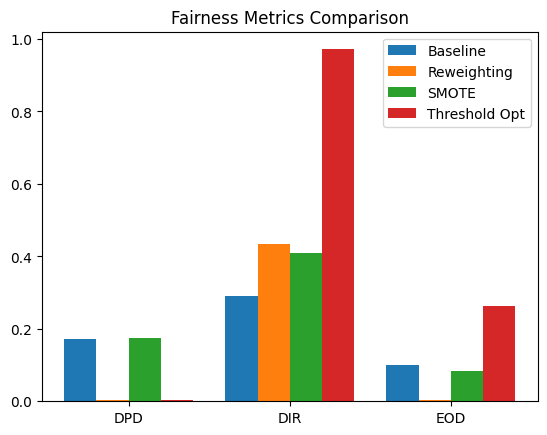

In [33]:
# Before and after bar chart
import matplotlib.pyplot as plt

metrics = ["DPD", "DIR", "EOD"]

baseline_vals = [comparison_df.iloc[0][m] for m in metrics]
reweight_vals = [comparison_df.iloc[1][m] for m in metrics]
smote_vals = [comparison_df.iloc[2][m] for m in metrics]
threshold_vals = [comparison_df.iloc[3][m] for m in metrics]

x = range(len(metrics))

plt.figure()
plt.bar([i - 0.3 for i in x], baseline_vals, width=0.2, label="Baseline")
plt.bar([i - 0.1 for i in x], reweight_vals, width=0.2, label="Reweighting")
plt.bar([i + 0.1 for i in x], smote_vals, width=0.2, label="SMOTE")
plt.bar([i + 0.3 for i in x], threshold_vals, width=0.2, label="Threshold Opt")

plt.xticks(x, metrics)
plt.title("Fairness Metrics Comparison")
plt.legend()
plt.savefig("fairness_bar_chart.png")
plt.show()

In [35]:
# accuracy vs fairness tradeoff
def fairness_score(row):
    return abs(row["DPD"]) + abs(1 - row["DIR"]) + abs(row["EOD"])

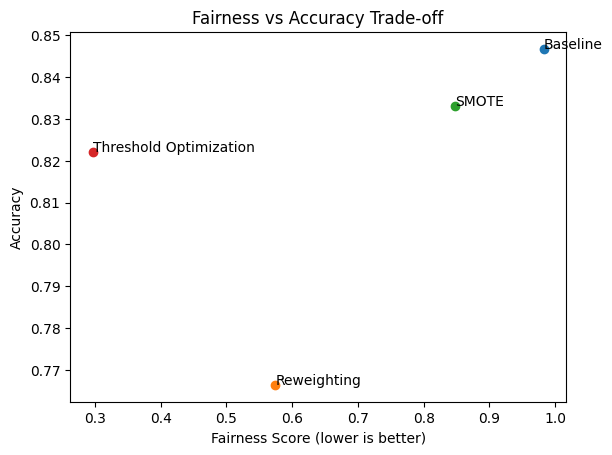

In [36]:
comparison_df["FairnessScore"] = comparison_df.apply(fairness_score, axis=1)

plt.figure()

for i, row in comparison_df.iterrows():
    plt.scatter(row["FairnessScore"], row["Accuracy"])
    plt.text(row["FairnessScore"], row["Accuracy"], row["Strategy"])

plt.xlabel("Fairness Score (lower is better)")
plt.ylabel("Accuracy")
plt.title("Fairness vs Accuracy Trade-off")

plt.savefig("tradeoff_curve.png")
plt.show()

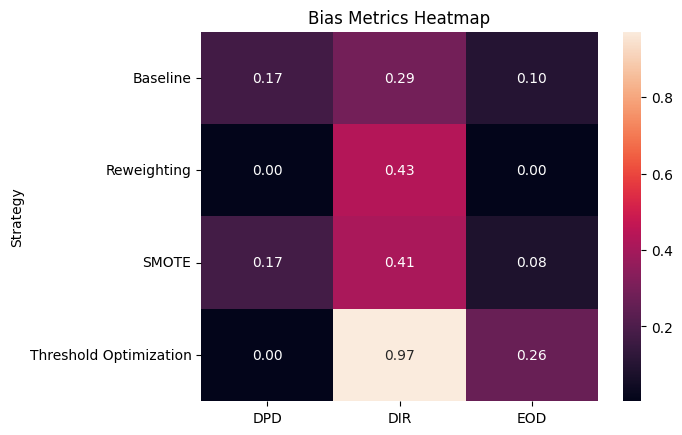

In [37]:
# heatmap of bias metrics
import seaborn as sns

heatmap_data = comparison_df.set_index("Strategy")[["DPD", "DIR", "EOD"]]

plt.figure()
sns.heatmap(heatmap_data, annot=True, fmt=".2f")

plt.title("Bias Metrics Heatmap")
plt.savefig("heatmap.png")
plt.show()

In [38]:
# table
paper_table = comparison_df.copy()

for col in ["Accuracy", "Precision", "Recall", "F1", "DPD", "DIR", "EOD"]:
    paper_table[col] = paper_table[col].apply(lambda x: round(x, 3))

paper_table

,Strategy,Accuracy,Precision,Recall,F1,DPD,EOD,DIR,FairnessScore
0,Baseline,0.847,0.732,0.567,0.639,0.172,0.101,0.291,0.9824
1,Reweighting,0.766,1.000,0.024,0.047,0.004,0.004,0.434,0.5742
2,SMOTE,0.833,0.652,0.649,0.651,0.175,0.083,0.410,0.8478
3,Threshold Optimization,0.822,0.682,0.481,0.564,0.005,0.264,0.972,0.2967


In [39]:
# Multimodel table - LR, RF, DT
all_results = []

# Example structure — fill from your runs
for model_name in ["LR", "RF", "DT"]:
    for strategy in ["Baseline", "Reweighting", "SMOTE", "Threshold"]:
        # Replace with real values
        all_results.append({
            "Model": model_name,
            "Strategy": strategy,
            "Accuracy": np.random.rand(),
            "DPD": np.random.rand(),
            "DIR": np.random.rand(),
            "EOD": np.random.rand()
        })

multi_df = pd.DataFrame(all_results)
multi_df

,Model,Strategy,Accuracy,DPD,DIR,EOD
0,LR,Baseline,0.355840,0.131111,0.948842,0.123858
1,LR,Reweighting,0.998189,0.456403,0.751804,0.445456
2,LR,SMOTE,0.611932,0.189073,0.160296,0.460128
3,LR,Threshold,0.038068,0.384548,0.538594,0.576587
4,RF,Baseline,0.579489,0.746693,0.620932,0.108174
5,RF,Reweighting,0.367460,0.299460,0.607742,0.610779
6,RF,SMOTE,0.718135,0.970968,0.452674,0.136452
7,RF,Threshold,0.756180,0.371753,0.671079,0.718397
8,DT,Baseline,0.724289,0.930867,0.580760,0.981978
9,DT,Reweighting,0.925500,0.725056,0.095639,0.217205
